In [1]:
# %%
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
device_ids = [0]

import gcsfs
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import xarray
from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm
import pandas as pd
import matplotlib.pyplot as plt

print(jax.devices())
gcs = gcsfs.GCSFileSystem(token='anon')

# %%
model_name = 'neuralgcm_04_30_2024_neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl'  #@param ['neural_gcm_dynamic_forcing_deterministic_0_7_deg.pkl', 'neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl', 'neural_gcm_dynamic_forcing_deterministic_2_8_deg.pkl', 'neural_gcm_dynamic_forcing_stochastic_1_4_deg.pkl'] {type: "string"}
                                                                                          # 1_4可用
# 载入模型权重
with open(f'/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/pkl/{model_name}', 'rb') as f:
   ckpt = pickle.load(f)

# %%
model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)  # 实例化NeuralGCM模型

# 如果需要同时获取物理核心结果和修正后结果，创建一个启用该功能的模型实例
# 这会在解码器中同时保存物理核心结果（不加深度学习修正）
model_with_physics = model.with_physics_core_output(enable=True)


print("模型分辨率为: ", 360/model.data_coords.horizontal.longitude_nodes)  # 360° 被 256 份均分，每格 360° / 256 ≈ 1.40625°

# %% [markdown]
# ## 批量处理辅助函数 (Batch Processing Helpers)

# %%
# 辅助函数: 堆叠和拆分字典列表
def stack_dicts(dicts_list):
    """Stacks a list of dictionaries into a single dictionary with a batch dimension."""
    return jax.tree_util.tree_map(lambda *args: jnp.stack(args), *dicts_list)

def unstack_dicts(batched_dict, batch_size):
    """Splits a batched dictionary back into a list of dictionaries."""
    # We iterate over the batch dimension for each leaf in the tree
    return [
        jax.tree_util.tree_map(lambda x: x[i], batched_dict)
        for i in range(batch_size)
    ]

# 处理多个 xarray.Dataset 为NeuralGCM批量输入
def prepare_batch_inputs(
    datasets_list: list[xarray.Dataset],
    model: neuralgcm.PressureLevelModel,
    inner_steps: int,
    outer_steps: int,
    times: np.ndarray,
) -> tuple[dict, dict, dict, list[xarray.Dataset], jax.Array]:
    """
    将多个 xarray.Dataset 处理为 NeuralGCM 的批量输入格式.
    假设输入的每个 Dataset 已经按需切片好:
    - 第 0 个时间步用于 inputs 和 input_forcings
    - 后续时间步用于 target_datasets
    
    Args:
        datasets_list: NeuralGCM能直接用的数据的 xarray.Dataset 列表.
        model: NeuralGCM 模型实例.
        inner_steps: 内部步数.
        outer_steps: 外部步数 (预测总步数).
        times: 时间数组.

    Returns:
        batched_inputs: 堆叠后的初始输入 (Batch, ...). 即初始场
        batched_input_forcings: 堆叠后的初始强迫项 (Batch, ...).
        batched_all_forcings: 堆叠后的全过程强迫项 (Batch, Time, ...).
        target_datasets: 用于对比的真实值 Dataset 列表. 其包括初始场
        batched_rng_keys: 对应的随机数 Key 列表.
    """
    inputs_list = []
    input_forcings_list = []
    all_forcings_list = []
    target_datasets = []

    print(f"正在处理 {len(datasets_list)} 个数据集...")

    for i, ds in enumerate(datasets_list):
        # 直接使用传入的 ds
        # 1. 准备 Inputs (t=0)
        # 取第 0 个时间步作为初始场
        current_inputs = model.inputs_from_xarray(ds.isel(time=0))
        current_input_forcings = model.forcings_from_xarray(ds.isel(time=0))
        
        # 2. 准备 Forcings (trajectory)
        # 保持 Persistence Forcing (取第 0 个时间步并保留维度)
        # 如果需要 Dynamic Forcing, 这里可能需要修改为取全部时间步
        current_all_forcings = model.forcings_from_xarray(ds.head(time=1))
        
        # 3. 准备真实值 (Target) 用于对比
        # 注意: Target 需要和预测的时间步对应
        # 这里假设输入的 ds 长度足以覆盖 outer_steps
        target_trajectory = model.inputs_from_xarray(
            ds
            .thin(time=(inner_steps // 1)) 
            .isel(time=slice(outer_steps))
        )  

        # .thin(time=k) 的意思是：在 time 维度上，每隔 k 个元素取 1 个。
        # slice(outer_steps) = [0, 1, ..., outer_steps-1], 即在跳跃取点后, 选择第0到outer_steps-1个元素, 由此可以看出target_trajectory包括初始场

        target_data_ds = model.data_to_xarray(target_trajectory, times=times)
        target_datasets.append(target_data_ds)

        inputs_list.append(current_inputs)
        input_forcings_list.append(current_input_forcings)
        all_forcings_list.append(current_all_forcings)

    # 堆叠成 batch
    batched_inputs = stack_dicts(inputs_list)
    batched_input_forcings = stack_dicts(input_forcings_list)
    batched_all_forcings = stack_dicts(all_forcings_list)

    # 准备随机数 key
    rng_key = jax.random.key(42)
    batched_rng_keys = jax.random.split(rng_key, len(datasets_list))

    return batched_inputs, batched_input_forcings, batched_all_forcings, target_datasets, batched_rng_keys


[cuda(id=0)]
模型分辨率为:  1.40625


In [2]:

file_configs = [
    ('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2022/04/01/20220401.nc', '2022-04-01 00:00:00'),
    ('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2021/01/01/20210101.nc', '2021-01-01 00:00:00'), # 解开注释以测试更多batch
    ('/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2021/01/05/20210105.nc', '2021-01-05 00:00:00'),
]

# 设置预测参数
inner_steps = 1  # save model outputs once every 24 hours
outer_steps = 24   # 1 * 20 // inner_steps  # 输出的总时间步数
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)
print("时间步为: ", times)

# 1. 在函数外读取文件到列表中
print("正在读取文件列表...")
loaded_datasets = []
start_times_list = []
for pth, start_time in file_configs:
    ds = xarray.open_dataset(pth, decode_timedelta=False)
    loaded_datasets.append(ds)
    start_times_list.append(start_time)


print(f"正在准备 {len(file_configs)} 个文件的数据...")
# 2. 将数据列表转换为NeuralGCM的堆叠输入
batched_inputs, batched_input_forcings, batched_all_forcings, target_datasets, batched_rng_keys = prepare_batch_inputs(
    datasets_list=loaded_datasets,
    model=model,
    inner_steps=inner_steps,
    outer_steps=outer_steps,
    times=times,
)


print("数据准备完成")


时间步为:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
正在读取文件列表...
正在准备 3 个文件的数据...
正在处理 3 个数据集...


2025-12-06 19:25:03.594171: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


数据准备完成


In [3]:
# 实例化批量encoder函数
print("编译批量推理函数...")
batched_encode_fn = jax.jit(jax.vmap(model.encode))

# 实例化批量预测函数
def unroll_wrapper(state, forcings):
    return model_with_physics.unroll(
        state,
        forcings,
        steps=outer_steps,
        timedelta=timedelta,
        start_with_input=True
    )  # start_with_input=True 表明输出数据的第一个时间步是初始场, 所以画图第一个点是初始场误差

batched_unroll_fn = jax.jit(jax.vmap(unroll_wrapper))

# 执行批量推理
print("执行批量编码 (Encoding)...")
batched_initial_state = batched_encode_fn(batched_inputs, batched_input_forcings, batched_rng_keys)

print("执行批量预测 (Unrolling)...")
batched_final_state, batched_predictions_with_physics = batched_unroll_fn(
    batched_initial_state, 
    batched_all_forcings
)

print("推理完成")

# 将批量结果拆分回列表
predictions_list = unstack_dicts(batched_predictions_with_physics, len(file_configs))

编译批量推理函数...
执行批量编码 (Encoding)...
执行批量预测 (Unrolling)...
推理完成


正在处理第 1/3 个结果...
绘制结果...


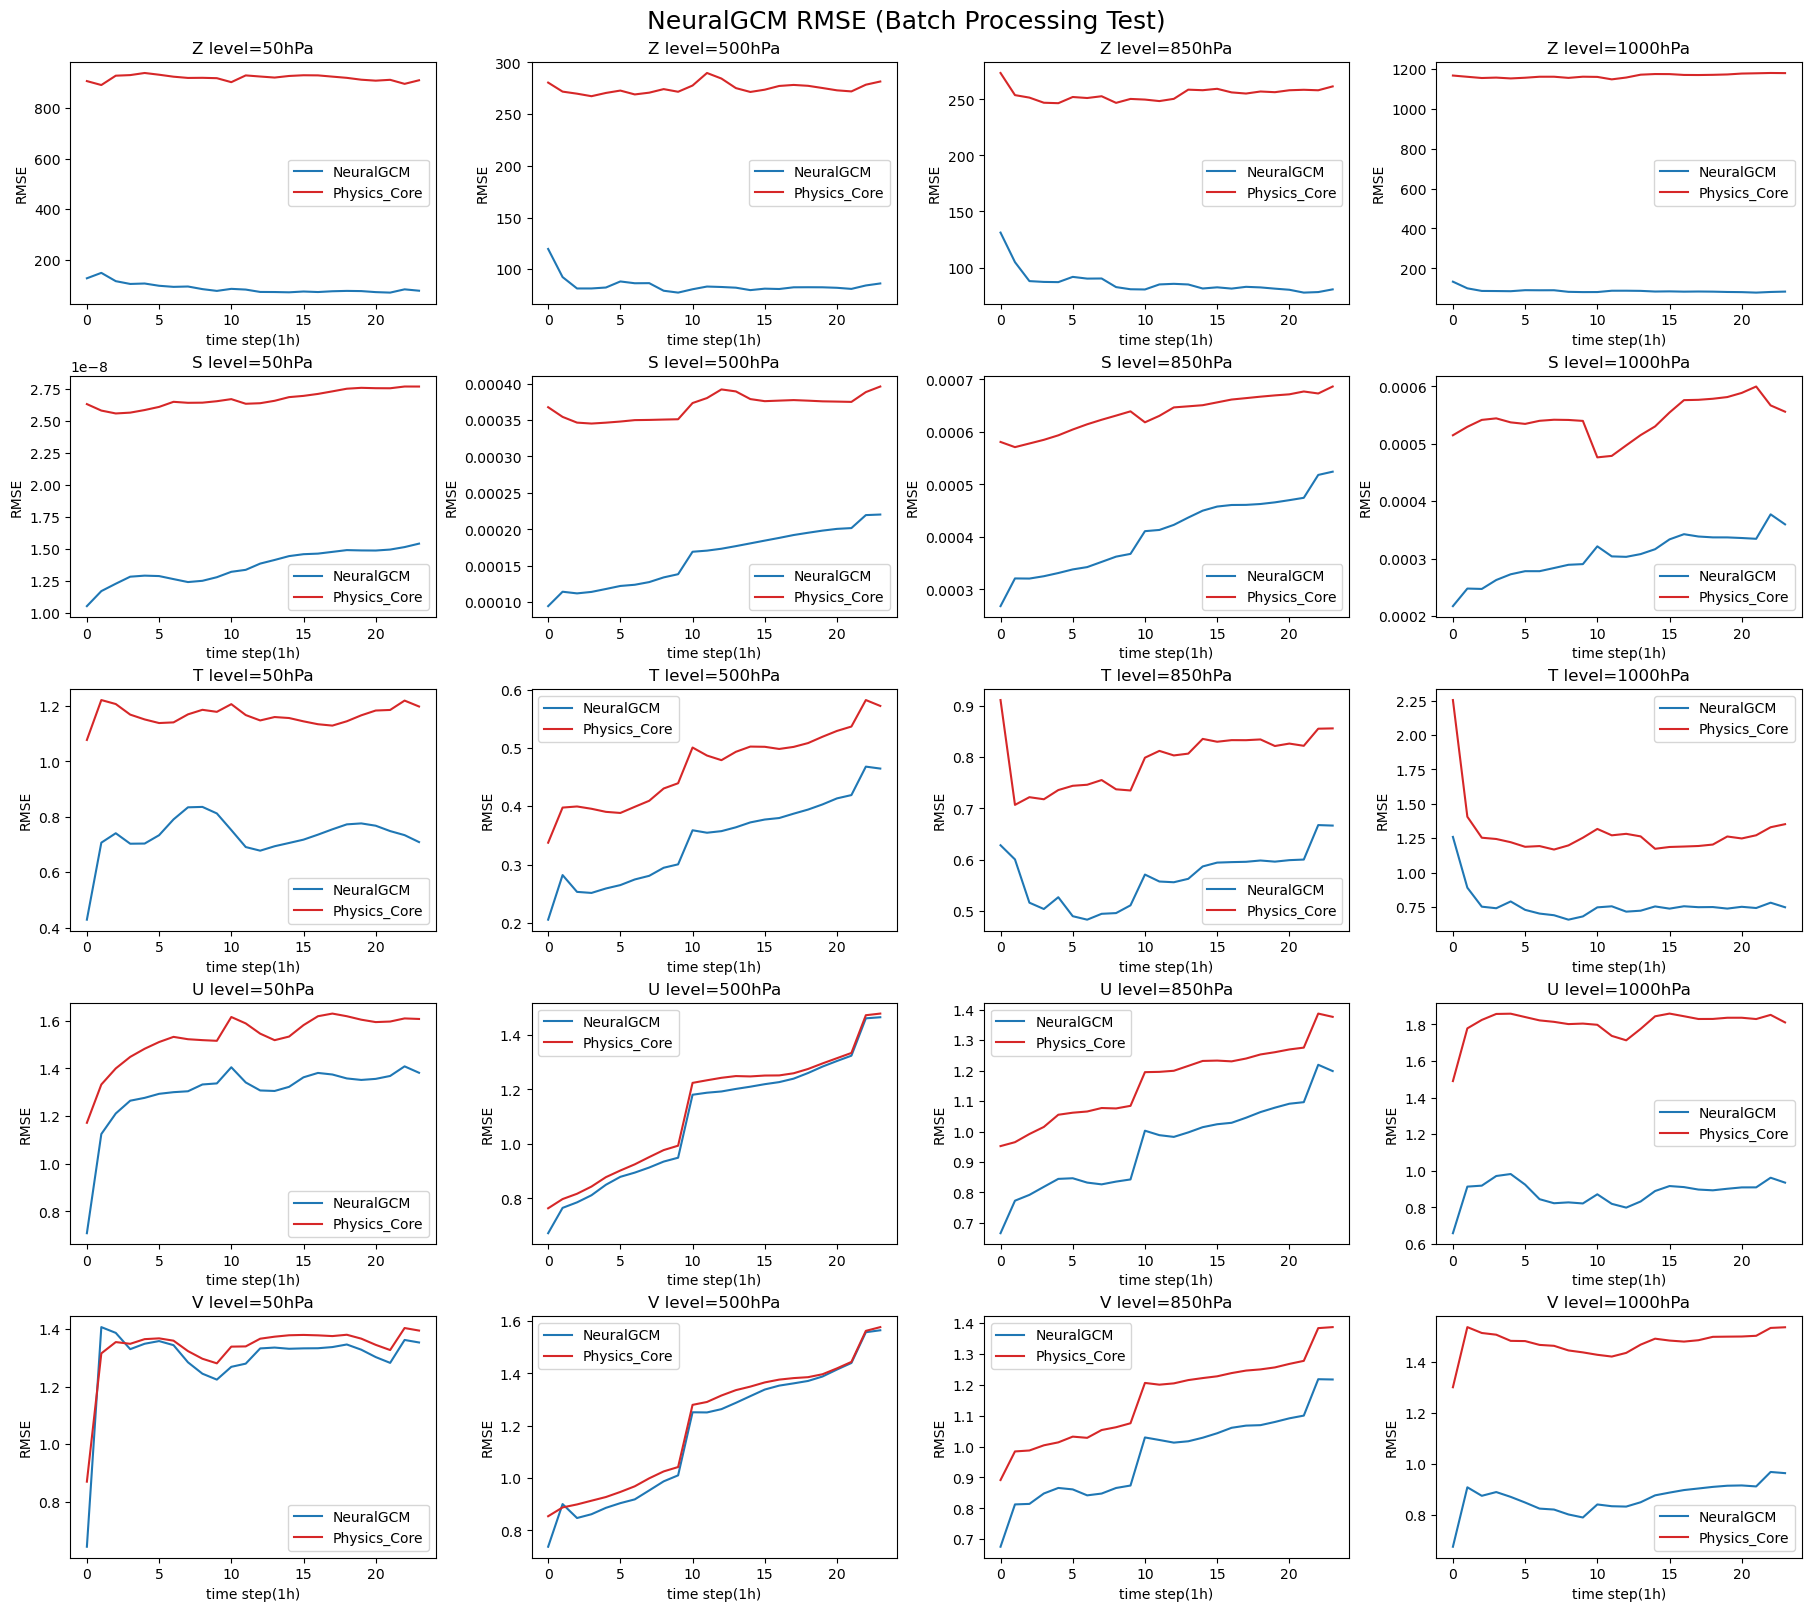

正在处理第 2/3 个结果...


In [ ]:
# 处理每个结果
results = []

for i, (pred_with_physics, target_ds) in enumerate(zip(predictions_list, target_datasets)):
    print(f"正在处理第 {i+1}/{len(file_configs)} 个结果...")
    
    # 分离物理核心和ML修正结果
    # 注意: data_to_xarray_with_physics 期望非 batch 的数据
    predictions_ds, predictions_phy_ds = model_with_physics.data_to_xarray_with_physics(
        pred_with_physics, times=times
    )
    
    # 拼接真实值
    combined_ds_with_physics = xarray.concat(
        [target_ds, predictions_phy_ds, predictions_ds], 
        'model'
    )
    combined_ds_with_physics.coords['model'] = ['ERA5', 'Physics_Core', 'NeuralGCM']
    
    results.append(combined_ds_with_physics)
    
    # 这里只对第一个文件进行绘图演示
    if i >= 0:
        print("绘制结果...")
        
        target = combined_ds_with_physics.sel(model="ERA5")
        baseline = combined_ds_with_physics.sel(model="NeuralGCM")
        baseline_phy = combined_ds_with_physics.sel(model="Physics_Core")
        
        diff = target - baseline
        diff_phy = target - baseline_phy
        
        var_map = {
            "z": "geopotential",
            "s": "specific_humidity",
            "t": "temperature",
            "u": "u_component_of_wind",
            "v": "v_component_of_wind",
        }
        levels_to_plot = [50, 500, 850, 1000]
        
        fig, axes = plt.subplots(
            nrows=len(var_map),
            ncols=len(levels_to_plot),
            figsize=(18, 16),
            sharex=False,
            constrained_layout=True,
        )
        
        for row_idx, (label, var_name) in enumerate(var_map.items()):
            da_full = diff[var_name]
            da_full_phy = diff_phy[var_name]

            for col_idx, level_value in enumerate(levels_to_plot):
                da = da_full.sel(level=level_value, method="nearest")
                da_phy = da_full_phy.sel(level=level_value, method="nearest")

                reduce_dims = [d for d in da.dims if d != "time"]
                reduce_dims_phy = [d for d in da_phy.dims if d != "time"]

                mse = (da**2).mean(dim=reduce_dims, skipna=True)
                mse_phy = (da_phy**2).mean(dim=reduce_dims_phy, skipna=True)

                rmse = np.sqrt(mse)
                rmse_phy = np.sqrt(mse_phy)

                ax = axes[row_idx, col_idx]
                rmse.plot(ax=ax, color="tab:blue", label="NeuralGCM")
                rmse_phy.plot(ax=ax, color="tab:red", label="Physics_Core")

                ax.set_title(f"{label.upper()} level={level_value}hPa")
                ax.set_xlabel("time step(1h)")
                ax.set_ylabel("RMSE")
                ax.legend()
        
        plt.suptitle("NeuralGCM RMSE (Batch Processing Test)", fontsize=18)
        plt.show()

# %%
